In [32]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1: The Plain Model (Cells 2-5)

**What we're modeling:** the paper's own method as-is -- ash already fully 
molten, sitting at a constant 1400 C, sliding down a tilted plate. Tested 
across all seven ash samples (Table 3) and all four incline angles.

**Why "plain":** assumes the heating-up part already happened before the 
calculation starts -- no time-varying anything here.

**Cells:**
- **2:** density, gravity, film thickness, angle, and viscosity for all seven ashes
- **3:** one worked example (Ash 2) using Equation 5
- **4:** travel length table for all seven ashes at 25 degrees
- **5:** travel length vs. angle, all seven ashes plotted together (reproduces 
  the paper's Figure 10)

**Limitation:** viscosity is fixed, never changes over time. Also doesn't 
know Ash 5-7 were too thick to flow at all at 1400 C in the paper's real 
tests -- our equation still gives them a small positive travel distance.

In [33]:
rho = 2700       # kg/m3, molten slag density, rough estimate
g = 9.81
delta = 5e-5     # film thickness, paper says <0.1mm
angle_deg = 25

ash_viscosities = {
    "Ash 1": 1.01,
    "Ash 2": 4.96,
    "Ash 3": 11.1,
    "Ash 4": 17.9,
    "Ash 5": 46.0,
    "Ash 6": 102.0,
    "Ash 7": 212.0,
}   # from Table 3 of the paper, at 1400C

beta = np.radians(angle_deg)

In [34]:
# quick check with just one ash before doing all seven
mu_value = ash_viscosities["Ash 2"]
v_avg = (rho * g * delta**2 * np.cos(beta)) / (3 * mu_value)

exposure_time_min = 40
exposure_time_s = exposure_time_min * 60

travel_length_mm = v_avg * exposure_time_s * 1000

print(f"velocity: {v_avg:.3e} m/s")
print(f"travel length after {exposure_time_min} min: {travel_length_mm:.3f} mm")

velocity: 4.033e-06 m/s
travel length after 40 min: 9.680 mm


In [35]:
print(f"{'Ash':<8}{'Viscosity (Pa.s)':<20}{'Travel length (mm)':<20}")

for ash_name, mu_value in ash_viscosities.items():
    v_avg = (rho * g * delta**2 * np.cos(beta)) / (3 * mu_value)
    travel_mm = v_avg * exposure_time_s * 1000
    print(f"{ash_name:<8}{mu_value:<20}{travel_mm:<20.3f}")

Ash     Viscosity (Pa.s)    Travel length (mm)  
Ash 1   1.01                47.535              
Ash 2   4.96                9.680               
Ash 3   11.1                4.325               
Ash 4   17.9                2.682               
Ash 5   46.0                1.044               
Ash 6   102.0               0.471               
Ash 7   212.0               0.226               


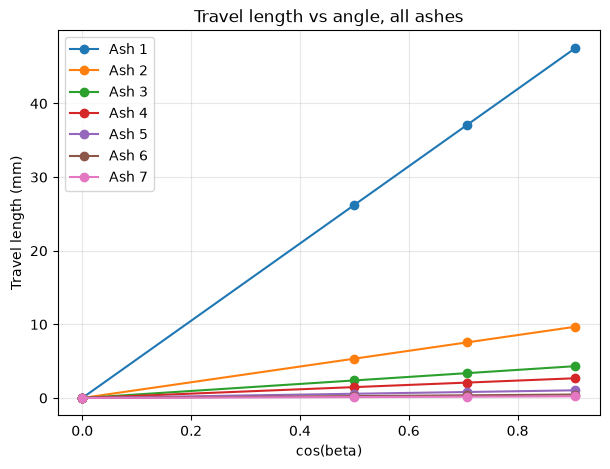

In [36]:
angles_deg = np.array([25, 45, 60, 90])
cos_betas = np.cos(np.radians(angles_deg))

plt.figure(figsize=(7, 5))
for ash_name, mu_value in ash_viscosities.items():
    v_avg_array = (rho * g * delta**2 * cos_betas) / (3 * mu_value)
    travel_mm_array = v_avg_array * exposure_time_s * 1000
    plt.plot(cos_betas, travel_mm_array, "o-", label=ash_name)

plt.xlabel("cos(beta)")
plt.ylabel("Travel length (mm)")
plt.title("Travel length vs angle, all ashes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Part 2: Lab Furnace Model (Cells 6-12)

**What we're modeling:** a furnace with no gradual pre-heating ramp (the setup 
Prof. Kamaraj described) -- solid ash dropped straight into one fixed high 
temperature, so it has to heat up in place before it can melt and flow. 
Part 1 skipped this; here it's modeled directly.

**Core idea:** temperature and flow are now linked and both change over time. 
As the sample heats up, viscosity drops, so flow speeds up -- even after 
flow has already started. Run separately for all seven ashes.

**Cells:**
- **6-7:** temperatures, per-ash melting thresholds (guessed for now), and 
  sample properties (mass, surface area, heat transfer coefficients, specific heat)
- **8:** heating rate function -- convection + radiation
- **9:** per-ash viscosity, calibrated to each ash's known value at furnace temp
- **10:** flow velocity -- Equation 5 plus a new friction term
- **11:** solves heating + flow together over 40 minutes, per ash, using `solve_ivp`
- **12:** plots temperature and travel distance vs. time, all seven ashes compared

**Placeholders still to refine:** melting thresholds, heat transfer 
coefficients, specific heat, and the Arrhenius temperature-sensitivity value.

In [37]:
T0_C = 25
T_furnace_C = 1400

# melting points are a guess for now, ordered roughly by silica content
# need real ash fusion data for these eventually
ash_T_melt_C = {
    "Ash 1": 1250,
    "Ash 2": 1280,
    "Ash 3": 1300,
    "Ash 4": 1320,
    "Ash 5": 1350,
    "Ash 6": 1370,
    "Ash 7": 1390,
}

T0 = T0_C + 273.15
T_furnace = T_furnace_C + 273.15
ash_T_melt = {ash: t + 273.15 for ash, t in ash_T_melt_C.items()}

In [38]:
mass = 0.2e-3
A_surf = 1.0e-4
h_conv = 20          # guess, depends on gas flow in the furnace
emissivity = 0.80
sigma_SB = 5.670374e-8

# same cp for all ashes for now - literature value for molten slag
ash_cp = {ash: 1300 for ash in ash_viscosities}

In [39]:
def heating_rate(T, cp_ash):
    q_conv = h_conv * A_surf * (T_furnace - T)
    q_rad = emissivity * sigma_SB * A_surf * (T_furnace**4 - T**4)
    return (q_conv + q_rad) / (mass * cp_ash)

In [40]:
R_gas = 8.314

# only have one real data point per ash (1400C, table 3)
# so using a shared E_A and anchoring A_A per ash to the known value
E_A_shared = 193000

ash_A_A = {}
for ash, eta_1400 in ash_viscosities.items():
    ash_A_A[ash] = eta_1400 * np.exp(-E_A_shared / (R_gas * T_furnace))

def viscosity(T, ash_name):
    return ash_A_A[ash_name] * np.exp(E_A_shared / (R_gas * T))

In [41]:
mu_friction = 0.15   # guess, slag on corundum

def flow_velocity(T, ash_name):
    driving = rho * g * delta * np.sin(beta)
    friction = mu_friction * rho * g * delta * np.cos(beta)
    net = driving - friction
    if net <= 0:
        return 0.0
    return net * delta / (3.0 * viscosity(T, ash_name))

In [42]:
from scipy.integrate import solve_ivp

def rhs(t, y, ash_name):
    T, x = y
    dTdt = heating_rate(T, ash_cp[ash_name])
    dxdt = flow_velocity(T, ash_name) if T >= ash_T_melt[ash_name] else 0.0
    return [dTdt, dxdt]

t_span = (0, 40 * 60)
t_eval = np.linspace(*t_span, 2000)
y0 = [T0, 0.0]

results = {}
for ash_name in ash_viscosities:
    sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, args=(ash_name,), method="RK45")
    results[ash_name] = sol

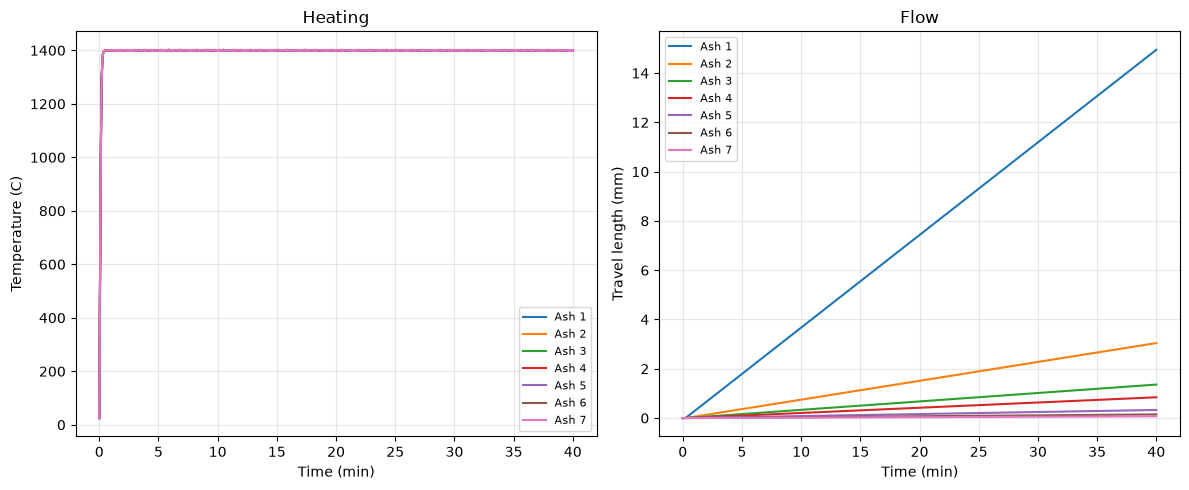

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for ash_name, sol in results.items():
    T_C = sol.y[0] - 273.15
    x_mm = sol.y[1] * 1000
    t_min = sol.t / 60
    ax[0].plot(t_min, T_C, label=ash_name)
    ax[1].plot(t_min, x_mm, label=ash_name)

ax[0].set_xlabel("Time (min)")
ax[0].set_ylabel("Temperature (C)")
ax[0].set_title("Heating")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

ax[1].set_xlabel("Time (min)")
ax[1].set_ylabel("Travel length (mm)")
ax[1].set_title("Flow")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()